In [2]:
# Level 3 - Task 3: NLP - Sentiment Analysis

## Social Media Sentiment Analysis

#This project applies Natural Language Processing (NLP) techniques to social
#media text data. The text is cleaned and preprocessed, and TextBlob is used
#to classify each text as Positive, Negative, or Neutral.

#The project also explores sentiment distribution and common words using
#visualizations and word clouds.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from textblob import TextBlob

In [4]:
df = pd.read_csv(r"D:\projects\codveda project\csv\3) Sentiment dataset.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,1/15/2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,1/15/2023 8:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,1/15/2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,1/15/2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,1/15/2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [5]:
df.shape

(732, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.1  732 non-null    int64 
 1   Unnamed: 0    732 non-null    int64 
 2   Text          732 non-null    object
 3   Sentiment     732 non-null    object
 4   Timestamp     732 non-null    object
 5   User          732 non-null    object
 6   Platform      732 non-null    object
 7   Hashtags      732 non-null    object
 8   Retweets      732 non-null    int64 
 9   Likes         732 non-null    int64 
 10  Country       732 non-null    object
 11  Year          732 non-null    int64 
 12  Month         732 non-null    int64 
 13  Day           732 non-null    int64 
 14  Hour          732 non-null    int64 
dtypes: int64(8), object(7)
memory usage: 85.9+ KB


In [7]:
df["Text"].head(10)

0     Enjoying a beautiful day at the park!        ...
1     Traffic was terrible this morning.           ...
2     Just finished an amazing workout! 💪          ...
3     Excited about the upcoming weekend getaway!  ...
4     Trying out a new recipe for dinner tonight.  ...
5     Feeling grateful for the little things in lif...
6     Rainy days call for cozy blankets and hot coc...
7     The new movie release is a must-watch!       ...
8     Political discussions heating up on the timel...
9     Missing summer vibes and beach days.         ...
Name: Text, dtype: object

In [8]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asust\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asust\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asust\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\asust\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\asust\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [9]:
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [11]:
sample_text = df["Text"].iloc[0]

print(sample_text)

 Enjoying a beautiful day at the park!              


In [12]:
text = sample_text.lower()
print(text)

 enjoying a beautiful day at the park!              


In [13]:
text = re.sub(r"[^a-z\s]", "", text)

print(text)

 enjoying a beautiful day at the park              


In [14]:
tokens = word_tokenize(text)

print(tokens)

['enjoying', 'a', 'beautiful', 'day', 'at', 'the', 'park']


In [15]:
tokens = [
    word for word in tokens
    if word not in stop_words
]

print(tokens)

['enjoying', 'beautiful', 'day', 'park']


In [16]:
stop_words.discard("not")
stop_words.discard("no")

In [17]:
tokens = [
    lemmatizer.lemmatize(word)
    for word in tokens
]

print(tokens)

['enjoying', 'beautiful', 'day', 'park']


In [18]:
cleaned_text = " ".join(tokens)

print(cleaned_text)

enjoying beautiful day park


In [19]:
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation, numbers and special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join tokens back into text
    return " ".join(tokens)

In [20]:
df["Cleaned_Text"] = df["Text"].apply(clean_text)

In [21]:
df[["Text", "Cleaned_Text"]].head(10)

,Text,Cleaned_Text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful little thing life
6,Rainy days call for cozy blankets and hot coc...,rainy day call cozy blanket hot cocoa
7,The new movie release is a must-watch! ...,new movie release mustwatch
8,Political discussions heating up on the timel...,political discussion heating timeline
9,Missing summer vibes and beach days. ...,missing summer vibe beach day


In [22]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

df["Polarity"] = df["Text"].apply(get_polarity)

In [23]:
df[["Text", "Polarity"]].head(10)

,Text,Polarity
0,Enjoying a beautiful day at the park! ...,0.750000
1,Traffic was terrible this morning. ...,-1.000000
2,Just finished an amazing workout! 💪 ...,0.750000
3,Excited about the upcoming weekend getaway! ...,0.468750
4,Trying out a new recipe for dinner tonight. ...,0.136364
5,Feeling grateful for the little things in lif...,-0.187500
6,Rainy days call for cozy blankets and hot coc...,0.025000
7,The new movie release is a must-watch! ...,0.170455
8,Political discussions heating up on the timel...,0.000000
9,Missing summer vibes and beach days. ...,-0.200000


In [24]:
def classify_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

In [25]:
df["Predicted_Sentiment"] = df["Polarity"].apply(classify_sentiment)

In [26]:
df[["Text", "Polarity", "Predicted_Sentiment"]].head(10)

,Text,Polarity,Predicted_Sentiment
0,Enjoying a beautiful day at the park! ...,0.750000,Positive
1,Traffic was terrible this morning. ...,-1.000000,Negative
2,Just finished an amazing workout! 💪 ...,0.750000,Positive
3,Excited about the upcoming weekend getaway! ...,0.468750,Positive
4,Trying out a new recipe for dinner tonight. ...,0.136364,Positive
5,Feeling grateful for the little things in lif...,-0.187500,Negative
6,Rainy days call for cozy blankets and hot coc...,0.025000,Neutral
7,The new movie release is a must-watch! ...,0.170455,Positive
8,Political discussions heating up on the timel...,0.000000,Neutral
9,Missing summer vibes and beach days. ...,-0.200000,Negative


In [27]:
df["Predicted_Sentiment"].value_counts()

Predicted_Sentiment
Neutral     342
Positive    271
Negative    119
Name: count, dtype: int64

In [28]:
df["Predicted_Sentiment"].value_counts(normalize=True) * 100

Predicted_Sentiment
Neutral     46.721311
Positive    37.021858
Negative    16.256831
Name: proportion, dtype: float64

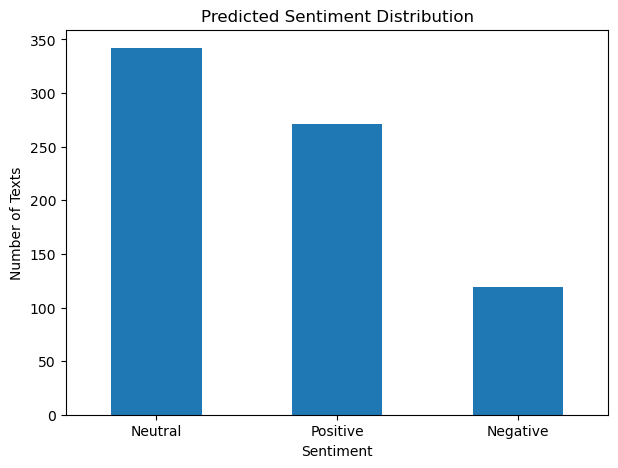

In [29]:
sentiment_counts = df["Predicted_Sentiment"].value_counts()

plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind="bar")

plt.title("Predicted Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.xticks(rotation=0)

plt.show()

In [30]:
### Sentiment Distribution Analysis

#The sentiment analysis classified 341 texts as Neutral, 272 as Positive,
#and 119 as Negative.

#Neutral sentiment is the most common category in the dataset, while
#negative sentiment is the least frequent. Positive sentiment also represents
#a substantial portion of the social media texts.

#This suggests that the overall dataset contains more neutral and positive
#content than negative content.

In [31]:
from collections import Counter

all_words = " ".join(df["Cleaned_Text"]).split()

word_counts = Counter(all_words)

word_counts.most_common(20)

[('new', 43),
 ('life', 38),
 ('day', 29),
 ('joy', 28),
 ('dream', 28),
 ('feeling', 27),
 ('moment', 27),
 ('like', 27),
 ('friend', 26),
 ('heart', 26),
 ('laughter', 24),
 ('night', 23),
 ('world', 22),
 ('art', 21),
 ('challenge', 21),
 ('echo', 21),
 ('time', 20),
 ('beauty', 20),
 ('journey', 20),
 ('emotion', 20)]

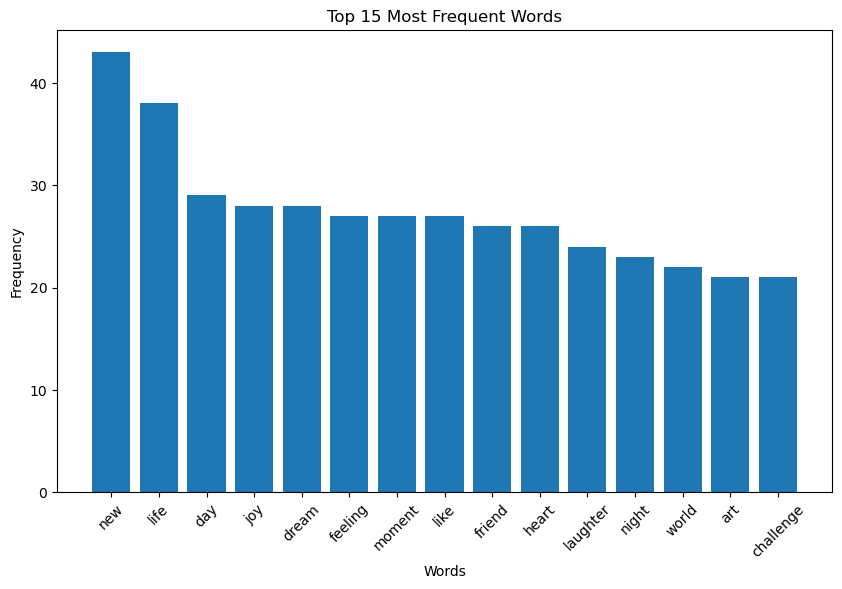

In [32]:
top_words = word_counts.most_common(15)

words = [word[0] for word in top_words]
counts = [word[1] for word in top_words]

plt.figure(figsize=(10, 6))

plt.bar(words, counts)

plt.title("Top 15 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [33]:
### Word Frequency Analysis

#The word-frequency analysis shows that "new", "life", "day", "joy",
#and "dream" are among the most frequently occurring words in the
#preprocessed social media texts.

#Several frequently occurring terms, such as "joy", "feeling", "heart",
#"laughter", "beauty", and "emotion", are directly related to emotions
#and personal experiences, which is consistent with the sentiment-focused
#nature of the dataset.

In [34]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


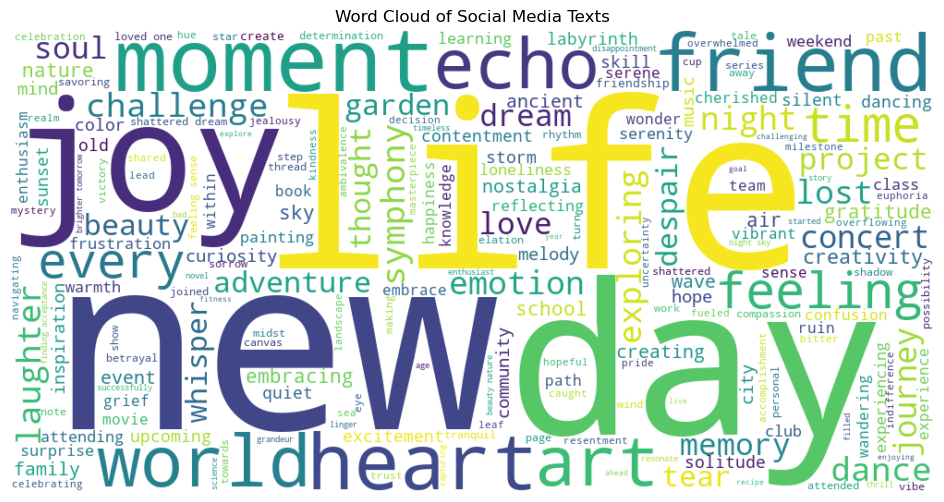

In [35]:
from wordcloud import WordCloud

text_for_wordcloud = " ".join(df["Cleaned_Text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_for_wordcloud)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Social Media Texts")

plt.show()

In [36]:
### Word Cloud Analysis

#The word cloud highlights the most frequently occurring terms in the
#preprocessed social media texts.

#Words such as "new", "life", "joy", "moment", "heart", "feeling",
#"dream", and "emotion" appear prominently, indicating that many texts
#focus on personal experiences, emotions, and everyday events.

#The word cloud represents word frequency rather than sentiment intensity,
#so larger words indicate more frequent occurrence, not necessarily
#stronger positive or negative sentiment.

In [37]:
## Final Conclusion

#This project applied Natural Language Processing techniques to analyze
#sentiment in a social media text dataset.

#The text data was preprocessed using lowercasing, tokenization, stopword
#removal, and lemmatization. TextBlob was then used to calculate polarity
#scores and classify each text as Positive, Negative, or Neutral.

#The sentiment analysis classified 341 texts as Neutral, 272 as Positive,
#and 119 as Negative. Neutral sentiment was the most common category,
#while negative sentiment was the least frequent.

#Word-frequency analysis showed that terms such as "new", "life", "day",
#"joy", and "dream" were among the most frequently occurring words.
#The word cloud also highlighted several emotion-related terms such as
#"heart", "feeling", "emotion", and "laughter".

#Overall, the analysis shows that the dataset contains a large proportion
#of neutral and positive content and that many of the texts are related
#to emotions, personal experiences, and everyday events.

#The sentiment labels produced in this project are based on TextBlob
#polarity scores and should therefore be interpreted as automated
#estimates rather than definitive sentiment labels.